# Configuration

In [1]:
import os 
import pickle 

if True ^ os.getcwd().endswith('hte-and-targeting'):
    os.chdir('..')


In [2]:
import random
import pandas as pd 
import numpy as np

from tqdm import tqdm

In [3]:
# visualization
import matplotlib.pyplot as plt
import seaborn as sns

# visualization params
# label size
tick_label_size = 12
legend_label_size = 12
axis_label_size = 14
title_size = 18
# font
plt.rcParams['font.family'] = 'serif'

In [4]:
from core.dgp import SingleSegment
import core.binary_treatment_single_segment as btss

# DGP

In [5]:
dgp = SingleSegment(
    **{'te': 1, 'noise_std': 1, 'treatment_space': np.array([0, 1])}
)
treatment_arr, outcome_arr = dgp.sample(sample_size=1000, seed=0)

# Demand Model

In [6]:
emp_te = btss.difference_in_mean(treatments=treatment_arr, outcomes=outcome_arr)

print(f'True Treatment Effect: {dgp.te:.2f}')
print(f'Estimated Treatment Effect: {emp_te:.2f}')

True Treatment Effect: 1.00
Estimated Treatment Effect: 1.13


# Optimization

$$
\begin{aligned}
V(\tau) & = \max\{p\tau - c, 0\} \\
& = \max\{p\tau, c\} - c \\ 
& = p \max\{\tau, c / p\} - c
\end{aligned}
$$

Optimal targeting policy $\pi$: 
$$
\pi(P, p, c) = \begin{cases}
1, \quad \text{if } \theta(P) \geq c / p \\ 
0, \quad \text{o.w.}
\end{cases}
$$

In [7]:
operations_params = {'price': 1.2, 'cost': 1}

plugin_decision, plugin_val_est = btss.optimize(te=emp_te, **operations_params)
true_plugin_val = btss.objective_func(
    targ_decision=plugin_decision, te=dgp.te, **operations_params
)


winners_curse = plugin_val_est - true_plugin_val
wc_mpe = winners_curse / true_plugin_val
wc_over_roi = winners_curse / operations_params['cost']

print(f'Plugin Decision: {plugin_decision}')
print(f'Estimated Targeting Value: {plugin_val_est:.2f}, ROI: {100 * plugin_val_est/operations_params["cost"]:.2f}%')
print(f'True Targeting Value: {true_plugin_val:.2f}, ROI: {100 * true_plugin_val/operations_params["cost"]:.2f}%')

print()
print(f"Winner's curse: {winners_curse:.4f}")
print(f"Winner's curse (measured in MPE): {100 * wc_mpe:.2f}%")
print(f"Winner's curse (measured in ROI): {100 * wc_over_roi:.2f}%")

Plugin Decision: True
Estimated Targeting Value: 0.36, ROI: 35.98%
True Targeting Value: 0.20, ROI: 20.00%

Winner's curse: 0.1598
Winner's curse (measured in MPE): 79.88%
Winner's curse (measured in ROI): 15.98%


## Shape of Value Function

In [8]:
def plot_value_function(
    price: float, cost: float, tau_lb: float, tau_ub: float, 
): 
    tau_arr = np.linspace(tau_lb, tau_ub, 1000)
    V_arr = np.maximum(tau_arr * price - cost, 0)

    fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

    # plot valuation function
    ax.plot(tau_arr, V_arr, color='black')

    # mark discontinuous point
    ax.plot(cost / price, 0, 'r*', markersize=20, label='Nondifferentiable Point')

    # plot attributes
    ax.tick_params(axis='both', which='major', labelsize=tick_label_size)
    ax.set_title('Optimal Targeting Value Function', fontsize=title_size)
    ax.set_xlabel('Treatment Effect', fontsize=axis_label_size)
    ax.set_ylabel('Optimal Targeting Value', fontsize=axis_label_size)
    ax.legend(loc='best', fontsize=legend_label_size)
    ax.grid()

    plt.tight_layout()
    plt.show()

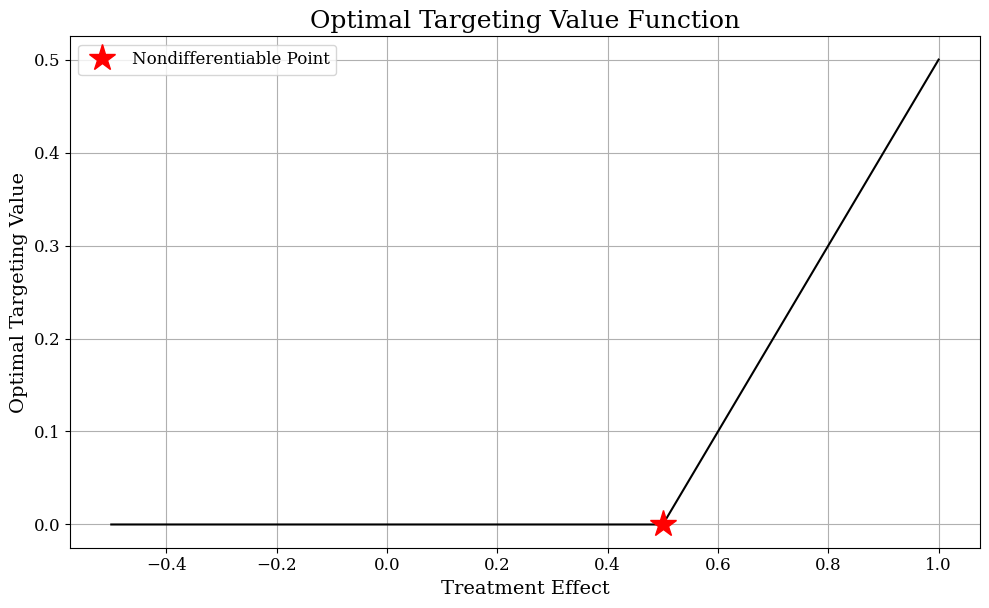

In [9]:
plot_value_function(price=1, cost=0.5, tau_lb=-0.5, tau_ub=1)

In [10]:
# clean memory
del dgp, treatment_arr, outcome_arr, emp_te, plugin_decision, plugin_val_est, true_plugin_val

# Winner's Curse

$$
\begin{aligned}
WC(\hat{\tau}) & = \max\{p\hat{\tau} - c, 0\} - (p\tau - c) \mathbb{I}\{\hat{\tau} \geq c / p\} \\
& = p (\hat{\tau} - \tau) \mathbb{I}\{\hat{\tau} \geq c / p\} \\ 
& = \begin{cases}
p (\hat{\tau} - \tau), \quad & \text{if } \hat{\tau} > c / p \\ 
0, \quad & \text{if } \hat{\tau} = c / p \\ 
0, \quad & \text{if } \hat{\tau} < c / p \\ 
\end{cases}
\end{aligned}
$$

Expected winner's curse: 
$$
WC = \mathrm{E}\left[ p (\hat{\tau} - \tau) \mathbb{I}\{\hat{\tau} \geq c / p\}\right]
$$

In [11]:
operations_params = {'price': 1.1, 'cost': 1}

dgp_params = {'te': 1, 'noise_std': 1, 'treatment_space': np.array([0, 1])}

data_params = {'sample_size': 100}

experiment_params = {'n_experiments': 10000, 'conditional_on_treated': True, 'stats': 'mean'} 

# empirical distribution of winner's curse
estimators_dict = {}

result_records = btss.repeated_experiments(
    operations_params=operations_params,
    dgp_params=dgp_params, 
    data_params=data_params, 
    experiment_params=experiment_params, 
    estimators_dict=estimators_dict
)

wc_measures_dict = btss.calculate_winners_curse_measures(
    result_records=result_records, operations_params=operations_params, 
    estimators_dict=estimators_dict, data_params=data_params
)

print(f"Average Winner's Curse: {wc_measures_dict['nc_wc_avg']:.4f} ({wc_measures_dict['nc_wc_se']:.4f})")
print(f"Average Winner's Curse Percentage of True Value: {100 * wc_measures_dict['nc_wc_pct_avg']:.2f}% ({100 * wc_measures_dict['nc_wc_pct_se']:.2f}%)")
print(f"Average Overestimated ROI: {100 * wc_measures_dict['nc_over_roi_avg']:.2f}% ({100 * wc_measures_dict['nc_over_roi_se']:.2f}%)")

print(f"\nRMSE={wc_measures_dict['nc_wc_rmse']:.4f}")

Average Winner's Curse: 0.1175 (0.0151)
Average Winner's Curse Percentage of True Value: 117.53% (15.10%)
Average Overestimated ROI: 11.75% (1.51%)

RMSE=0.1914


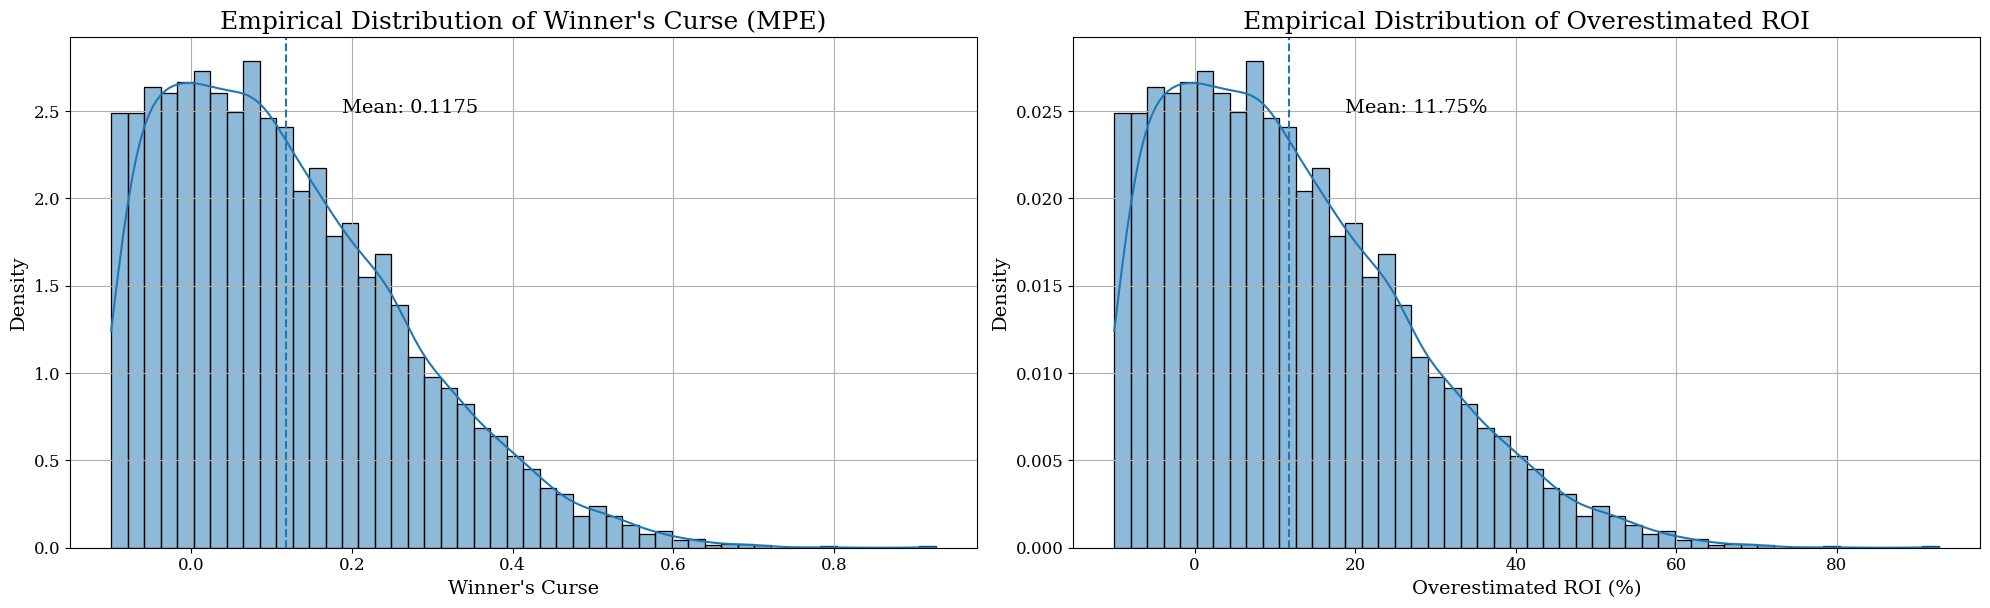

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(20, 6.18))

sns.histplot(wc_measures_dict['nc_wc_arr'], bins=50, kde=True, stat='density', ax=axes[0], color='C0')
axes[0].axvline(wc_measures_dict['nc_wc_avg'], color='C0', linestyle='--')
axes[0].annotate(
    f"Mean: {wc_measures_dict['nc_wc_avg']:.4f}", 
    xy=(0.3, 0.85), xycoords='axes fraction', fontsize=axis_label_size
)
axes[0].set_title("Empirical Distribution of Winner's Curse (MPE)", fontsize=title_size)

axes[0].tick_params(axis='both', which='major', labelsize=tick_label_size)
axes[0].set_xlabel("Winner's Curse", fontsize=axis_label_size)
axes[0].set_ylabel('Density', fontsize=axis_label_size)
axes[0].grid()

sns.histplot(100 * wc_measures_dict['nc_over_roi_arr'], bins=50, kde=True, stat='density', ax=axes[1], color='C0')
axes[1].axvline(100 * wc_measures_dict['nc_over_roi_avg'], color='C0', linestyle='--')
axes[1].annotate(
    f"Mean: {100 * wc_measures_dict['nc_over_roi_avg']:.2f}%", 
    xy=(0.3, 0.85), xycoords='axes fraction', fontsize=axis_label_size
)
axes[1].set_title("Empirical Distribution of Overestimated ROI", fontsize=title_size)
axes[1].tick_params(axis='both', which='major', labelsize=tick_label_size)
axes[1].set_xlabel("Overestimated ROI (%)", fontsize=axis_label_size)
axes[1].set_ylabel('Density', fontsize=axis_label_size)
axes[1].grid()

plt.tight_layout()
plt.savefig('figures/case2-winners-curse-dstn.png')
plt.show()

# Estimating winner's curse

In [13]:
dgp = SingleSegment(**dgp_params)
treatment_arr, outcome_arr = dgp.sample(**data_params, seed=1)

## Standard Bootstrap

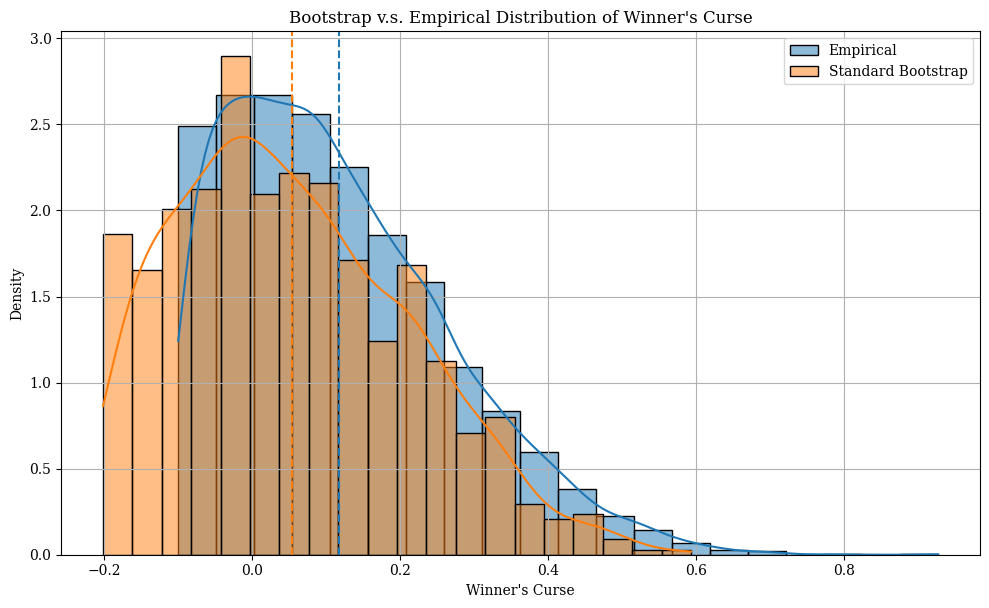

In [14]:
# generate bootstrap distribution
boot_wc_dstn_arr = btss.get_wc_boot_dstn(
    treatments=treatment_arr, outcomes=outcome_arr,
    **operations_params, n_bootstraps=1000, conditional_on_treated=True, 
)

fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

sns.histplot(wc_measures_dict['nc_wc_arr'], bins=20, kde=True, stat='density', ax=ax, color='C0', label='Empirical')
ax.axvline(wc_measures_dict['nc_wc_avg'], color='C0', linestyle='--')

sns.histplot(boot_wc_dstn_arr, bins=20, kde=True, stat='density', ax=ax, color='C1', label='Standard Bootstrap')
ax.axvline(boot_wc_dstn_arr.mean(), color='C1', linestyle='--')

ax.set_title("Bootstrap v.s. Empirical Distribution of Winner's Curse")
ax.set_xlabel("Winner's Curse")
ax.set_ylabel('Density')
ax.legend()
ax.grid()

plt.tight_layout()
plt.show()

## m-out-of-n Bootstrap

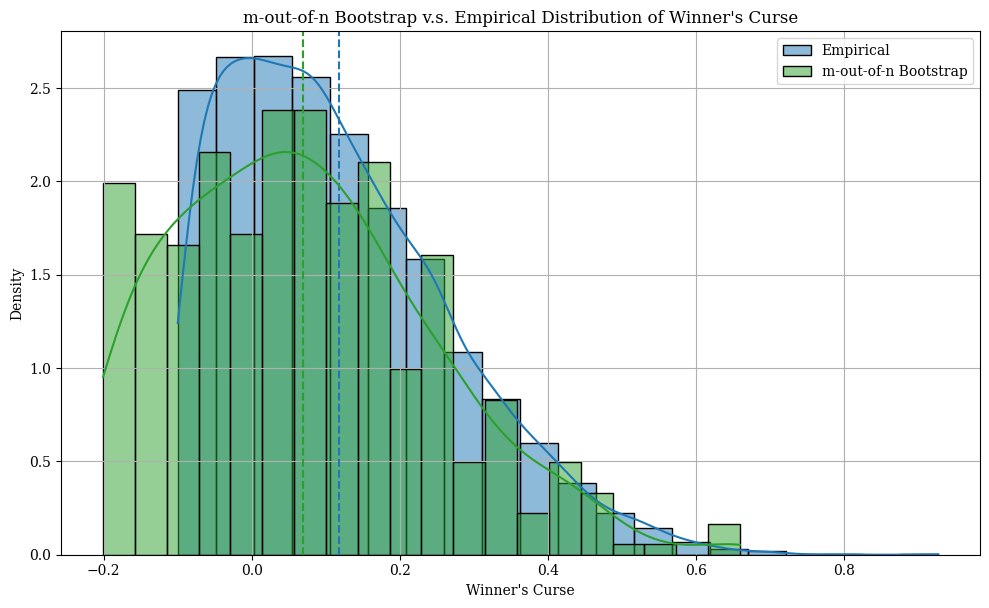

In [15]:
# generate bootstrap distribution
mn_boot_wc_dstn_arr = btss.get_wc_m_out_of_n_boot_dstn(
    treatments=treatment_arr, outcomes=outcome_arr, **operations_params, 
    n_bootstraps=500, power=0.95, conditional_on_treated=True
)
# mn_boot_wc_dstn_arr /= clairvoyant_opt_obj

fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

sns.histplot(wc_measures_dict['nc_wc_arr'], bins=20, kde=True, stat='density', ax=ax, color='C0', label='Empirical')
ax.axvline(wc_measures_dict['nc_wc_avg'], color='C0', linestyle='--')

sns.histplot(mn_boot_wc_dstn_arr, bins=20, kde=True, stat='density', ax=ax, color='C2', label='m-out-of-n Bootstrap')
ax.axvline(mn_boot_wc_dstn_arr.mean(), color='C2', linestyle='--')

ax.set_title("m-out-of-n Bootstrap v.s. Empirical Distribution of Winner's Curse")
ax.set_xlabel("Winner's Curse")
ax.set_ylabel('Density')
ax.legend()
ax.grid()

plt.tight_layout()
plt.show()

## Numerical Bootstrap

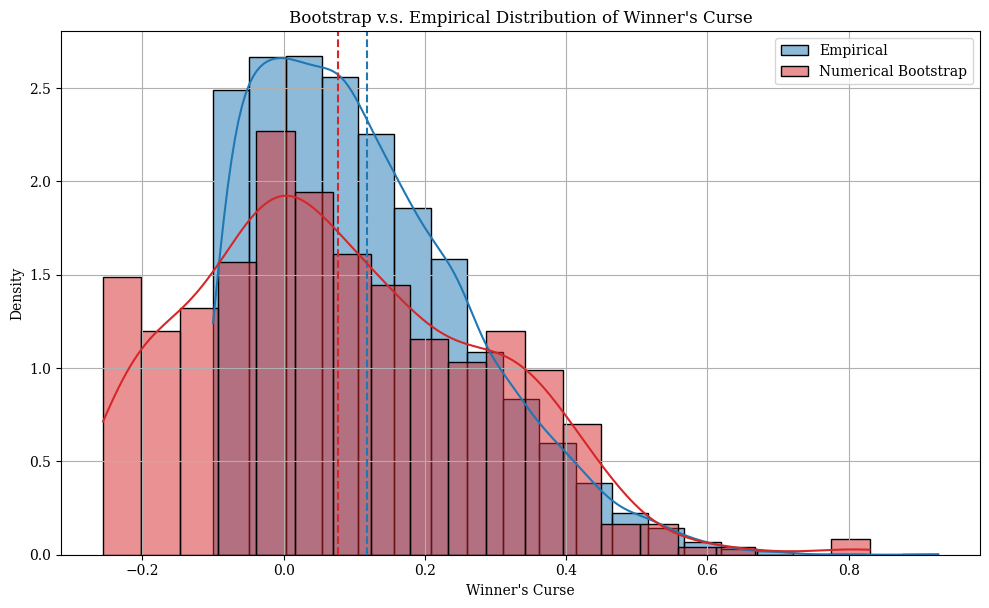

In [16]:
# generate bootstrap distribution
num_boot_wc_dstn_arr = btss.get_wc_num_boot_dstn(
    treatments=treatment_arr, outcomes=outcome_arr, **operations_params, 
    n_bootstraps=500, power=-0.45, conditional_on_treated=True
)
# num_boot_wc_dstn_arr /= clairvoyant_opt_obj

fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

sns.histplot(wc_measures_dict['nc_wc_arr'], bins=20, kde=True, stat='density', ax=ax, color='C0', label='Empirical')
ax.axvline(wc_measures_dict['nc_wc_avg'], color='C0', linestyle='--')

sns.histplot(num_boot_wc_dstn_arr, bins=20, kde=True, stat='density', ax=ax, color='C3', label='Numerical Bootstrap')
ax.axvline(num_boot_wc_dstn_arr.mean(), color='C3', linestyle='--')

ax.set_title("Bootstrap v.s. Empirical Distribution of Winner's Curse")
ax.set_xlabel("Winner's Curse")
ax.set_ylabel('Density')
ax.legend()
ax.grid()

plt.tight_layout()
plt.show()

# Bias Correction

## Correcting the Avg. Winner's Curse Conditional on Treated

In [20]:
operations_params = {'price': 1.1, 'cost': 1}

dgp_params = {'te': 1, 'noise_std': 1, 'treatment_space': np.array([0, 1])}

data_params = {'sample_size': 200}

experiment_params = {'n_experiments': 5000, 'conditional_on_treated': True, 'stats': 'mean'}

estimators_dict = {
    'sample_splitting': {
        'estimator': btss.sample_splitting_estimate, 
        'params': {}, 
    }, 
    'empirical_bayes': {
        'estimator': btss.empirical_bayes_estimate, 
        'params': {'n_degree': 5, 'n_knots': 2, 'bin_width': 0.1, 'smoothing': 0.5}
    }, 
    'normal_prior_bayes': {
        'estimator': btss.normal_prior_bayes_estimate, 
        'params': {'prior_mean': 0, 'prior_std': 1}
    }, 
    'standard_bootstrap': {
        'estimator': btss.bootstrap_correction_estimate, 
        'params': {
            'n_bootstraps': 1000, 'bootstrap_method': 'standard',
        }
    }, 
    'mn_bootstrap': {
        'estimator': btss.bootstrap_correction_estimate, 
        'params': {
            'n_bootstraps': 1000, 'bootstrap_method': 'm_out_of_n', 
            'power': 0.95,
        }
    }, 
    'num_bootstrap': {
        'estimator': btss.bootstrap_correction_estimate, 
        'params': {
            'n_bootstraps': 1000, 'bootstrap_method': 'numerical', 
            'power': - 0.45,
        }
    }
}

In [21]:
result_records = btss.repeated_experiments(
    operations_params=operations_params, 
    dgp_params=dgp_params, 
    data_params=data_params, 
    experiment_params=experiment_params, 
    estimators_dict=estimators_dict, 
    verbose=True, n_jobs=-1
)

wc_measures_dict = btss.calculate_winners_curse_measures(
    result_records=result_records, operations_params=operations_params, 
    estimators_dict=estimators_dict, data_params=data_params
)

Running 5000 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 208 tasks      | elapsed:    2.1s
[Parallel(n_jobs=-1)]: Done 708 tasks      | elapsed:    7.0s
[Parallel(n_jobs=-1)]: Done 1408 tasks      | elapsed:   14.0s
[Parallel(n_jobs=-1)]: Done 2308 tasks      | elapsed:   22.8s
[Parallel(n_jobs=-1)]: Done 3408 tasks      | elapsed:   33.8s
[Parallel(n_jobs=-1)]: Done 4708 tasks      | elapsed:   46.8s
[Parallel(n_jobs=-1)]: Done 4937 out of 5000 | elapsed:   49.0s remaining:    0.5s
[Parallel(n_jobs=-1)]: Done 5000 out of 5000 | elapsed:   49.6s finished


In [22]:
for estimator in ['nc'] + list(estimators_dict.keys()):
    print(f"\nWinner's Curse of {estimator}: {wc_measures_dict[f'{estimator}_wc_avg']:.4f} ({wc_measures_dict[f'{estimator}_wc_se']:.4f})", end=', ')
    print(f"Percentage of True Value: {100 * wc_measures_dict[f'{estimator}_wc_pct_avg']:.2f}% ({100 * wc_measures_dict[f'{estimator}_wc_pct_se']:.2f}%)", end=', ')
    print(f"RMSE={wc_measures_dict[f'{estimator}_wc_rmse']:.4f}")

    print(f"Overestiamted ROI of {estimator}: {100 * wc_measures_dict[f'{estimator}_over_roi_avg']:.2f}% ({100 * wc_measures_dict[f'{estimator}_over_roi_se']:.2f}%)")


Winner's Curse of nc: 0.0701 (0.0081), Percentage of True Value: 70.07% (8.09%), RMSE=0.1341
Overestiamted ROI of nc: 7.01% (0.81%)

Winner's Curse of sample_splitting: 0.0359 (0.0123), Percentage of True Value: 44.87% (13.73%), RMSE=0.1783
Overestiamted ROI of sample_splitting: 3.59% (1.23%)

Winner's Curse of empirical_bayes: 0.0700 (0.0101), Percentage of True Value: 69.98% (10.11%), RMSE=0.1592
Overestiamted ROI of empirical_bayes: 7.00% (1.01%)

Winner's Curse of normal_prior_bayes: 0.0626 (0.0080), Percentage of True Value: 62.64% (8.01%), RMSE=0.1295
Overestiamted ROI of normal_prior_bayes: 6.26% (0.80%)

Winner's Curse of standard_bootstrap: 0.0196 (0.0105), Percentage of True Value: 19.58% (10.48%), RMSE=0.1494
Overestiamted ROI of standard_bootstrap: 1.96% (1.05%)

Winner's Curse of mn_bootstrap: 0.0062 (0.0108), Percentage of True Value: 6.16% (10.79%), RMSE=0.1527
Overestiamted ROI of mn_bootstrap: 0.62% (1.08%)

Winner's Curse of num_bootstrap: 0.0044 (0.0112), Percentage

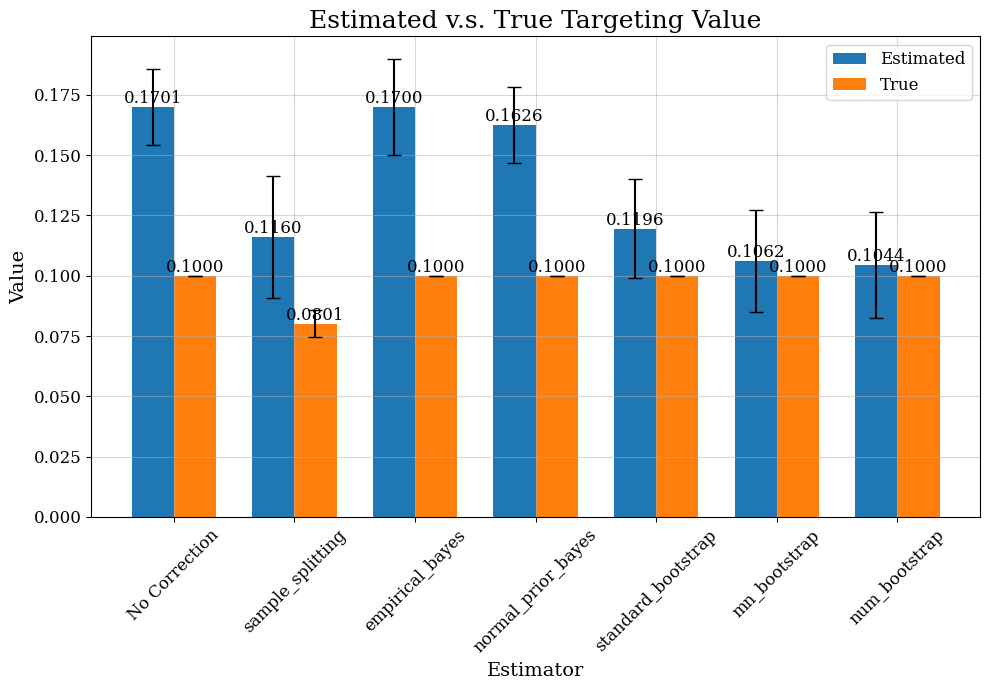

In [23]:
fig, ax = plt.subplots(1, 1, figsize=(10, 7))

x = np.arange(len(estimators_dict) + 1)
width = 0.35

ax.bar(
    x - width/2, 
    height=[wc_measures_dict[f'{estimator}_val_est_avg'] for estimator in ['nc'] + list(estimators_dict.keys())],
    yerr=[1.96 * wc_measures_dict[f'{estimator}_val_est_se'] for estimator in ['nc'] + list(estimators_dict.keys())],
    capsize=5, 
    width=width, label='Estimated', color='C0'
)

ax.bar(
    x + width/2, 
    height=[wc_measures_dict[f'{estimator}_val_true_avg'] for estimator in ['nc'] + list(estimators_dict.keys())],
    yerr=[1.96 * wc_measures_dict[f'{estimator}_val_true_se'] for estimator in ['nc'] + list(estimators_dict.keys())],
    capsize=5, 
    width=width, label='True', color='C1'
)

# add text annotation
for i, (val_est, val_true) in enumerate(zip(
    [wc_measures_dict[f'{estimator}_val_est_avg'] for estimator in ['nc'] + list(estimators_dict.keys())],
    [wc_measures_dict[f'{estimator}_val_true_avg'] for estimator in ['nc'] + list(estimators_dict.keys())]
)):
    ax.text(
        i - width/2, val_est, f"{val_est:.4f}", 
        ha='center', va='bottom', fontsize=tick_label_size
    )
    ax.text(
        i + width/2, val_true, f"{val_true:.4f}", 
        ha='center', va='bottom', fontsize=tick_label_size
    )

ax.set_title("Estimated v.s. True Targeting Value", fontsize=title_size)
ax.set_xlabel("Estimator", fontsize=axis_label_size)
ax.set_ylabel("Value", fontsize=axis_label_size)
ax.set_xticks(x)
ax.set_xticklabels(['No Correction'] + list(estimators_dict.keys()), rotation=45)
ax.tick_params(axis='both', which='major', labelsize=tick_label_size)

ax.legend(['Estimated', 'True'], fontsize=legend_label_size)
ax.grid(alpha=0.5)

plt.tight_layout()
plt.show()

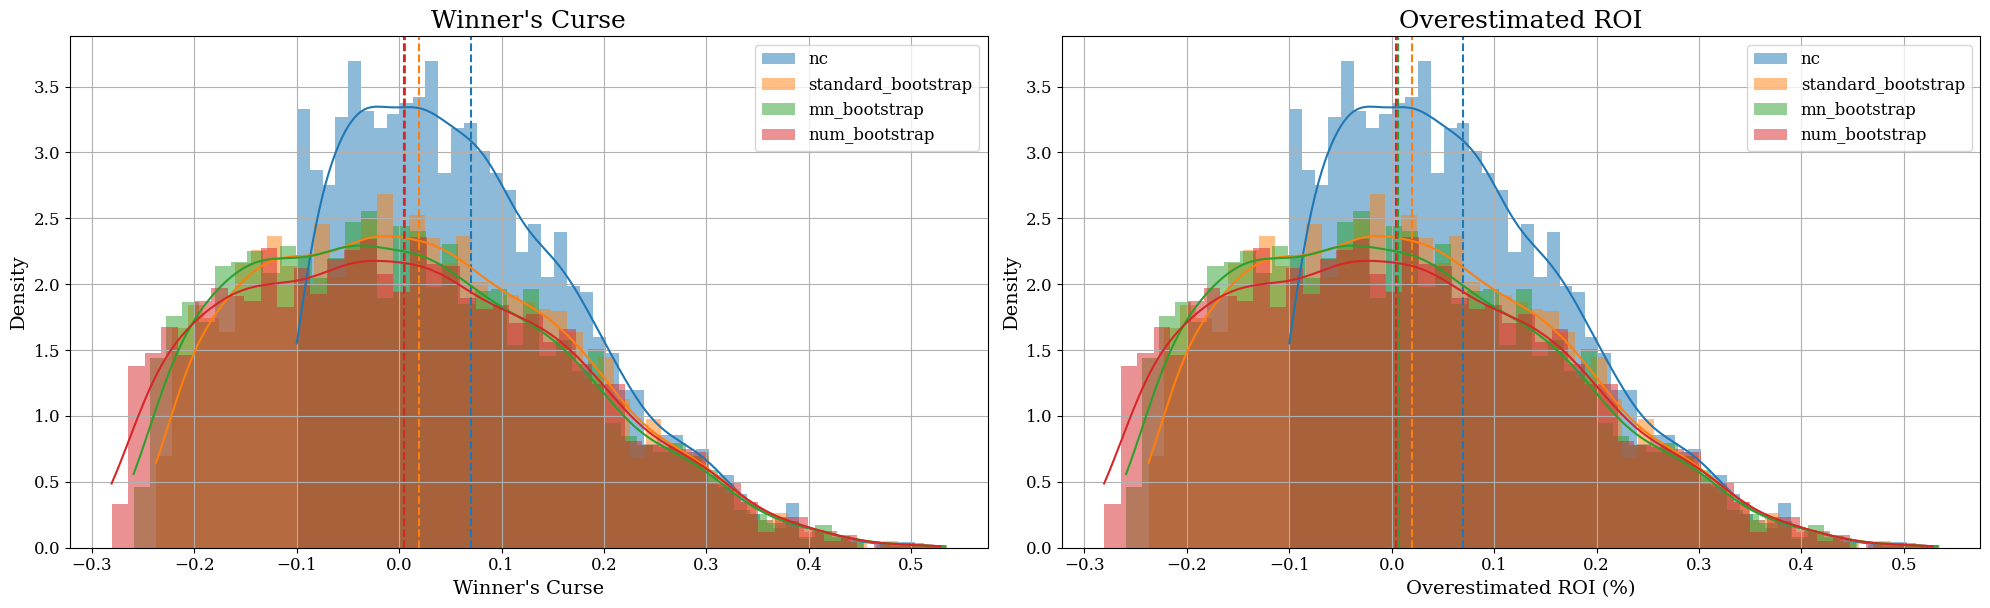

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(20, 6.18))

# winner's curse MPE
for idx, estimator in enumerate(['nc', 'standard_bootstrap', 'mn_bootstrap', 'num_bootstrap']):
    sns.histplot(wc_measures_dict[f"{estimator}_wc_arr"], bins=50, kde=True, stat='density', ax=axes[0], color=f'C{idx}', edgecolor=None, label=estimator)
    axes[0].axvline(wc_measures_dict[f"{estimator}_wc_avg"], color=f'C{idx}', linestyle='--')

axes[0].set_title('Winner\'s Curse', fontsize=title_size)
axes[0].set_xlabel('Winner\'s Curse', fontsize=axis_label_size)

# overestimated ROI
for idx, estimator in enumerate(['nc', 'standard_bootstrap', 'mn_bootstrap', 'num_bootstrap']):
    sns.histplot(wc_measures_dict[f"{estimator}_over_roi_arr"], bins=50, kde=True, stat='density', ax=axes[1], color=f'C{idx}', edgecolor=None, label=estimator)
    axes[1].axvline(wc_measures_dict[f"{estimator}_over_roi_avg"], color=f'C{idx}', linestyle='--')

axes[1].set_title('Overestimated ROI', fontsize=title_size)
axes[1].set_xlabel('Overestimated ROI (%)', fontsize=axis_label_size)

for ax in axes:
    ax.tick_params(labelsize=tick_label_size)
    ax.legend(fontsize=legend_label_size)
    ax.set_ylabel('Density', fontsize=axis_label_size)
    ax.grid()

plt.tight_layout()
# plt.savefig('figures/case1-bias-correction.png')
plt.show()

## Correcting the Median of Winner's Curse Conditional on Treated

In [42]:
operations_params = {'price': 1, 'cost': 0.5}

dgp_params = {'te': 0.6, 'noise_std': 2, 'treatment_space': np.array([0, 1])}

data_params = {'sample_size': 200}

experiment_params = {'n_experiments': 5000, 'conditional_on_treated': True, 'stats': 'median'}

estimators_dict = {
    'stand_bootstrap': {
        'estimator': btss.bootstrap_correction_estimate, 
        'params': {
            'n_bootstraps': 1000, 'bootstrap_method': 'standard',
        }
    }, 
    'mn_bootstrap': {
        'estimator': btss.bootstrap_correction_estimate, 
        'params': {
            'n_bootstraps': 1000, 'bootstrap_method': 'm_out_of_n', 
            'power': 0.9,
        }
    }, 
    'num_bootstrap': {
        'estimator': btss.bootstrap_correction_estimate, 
        'params': {
            'n_bootstraps': 1000, 'bootstrap_method': 'numerical', 
            'power': - 0.4,
        }
    }
}

In [43]:
result_records = btss.repeated_experiments(
    operations_params=operations_params, 
    dgp_params=dgp_params, 
    data_params=data_params, 
    experiment_params=experiment_params, 
    estimators_dict=estimators_dict, 
    verbose=True, n_jobs=-1
)

Running 5000 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.5s
[Parallel(n_jobs=-1)]: Done 340 tasks      | elapsed:    3.2s
[Parallel(n_jobs=-1)]: Done 840 tasks      | elapsed:    7.8s
[Parallel(n_jobs=-1)]: Done 1540 tasks      | elapsed:   14.1s
[Parallel(n_jobs=-1)]: Done 2440 tasks      | elapsed:   22.2s
[Parallel(n_jobs=-1)]: Done 3540 tasks      | elapsed:   32.6s
[Parallel(n_jobs=-1)]: Done 4840 tasks      | elapsed:   45.0s
[Parallel(n_jobs=-1)]: Done 5000 out of 5000 | elapsed:   46.3s finished


In [44]:
wc_pct_df = pd.DataFrame.from_records({
    f'{name}': 100 * np.array([record[f'{name}_wc_pct'] for record in result_records])
    for name in ['plugin'] + list(estimators_dict.keys())
})
roi_wc_df = pd.DataFrame.from_records({
    f'{name}': 100 * np.array([record[f'{name}_roi_wc'] for record in result_records])
    for name in ['plugin'] + list(estimators_dict.keys())
})

       mn_bootstrap  num_bootstrap       plugin  stand_bootstrap
count   3223.000000    3223.000000  3223.000000      3223.000000
mean      44.086150      35.414799   169.439248        90.425512
std      258.474218     282.196447   191.794914       244.178803
min     -408.322726    -480.482744   -99.586906      -309.881929
25%     -163.463184    -194.159527    14.980095      -108.727771
50%       11.137348      13.105990   136.241182        62.378498
75%      220.846762     241.320891   287.951909       259.733105
max      966.698547     929.425151   960.485807       953.542654


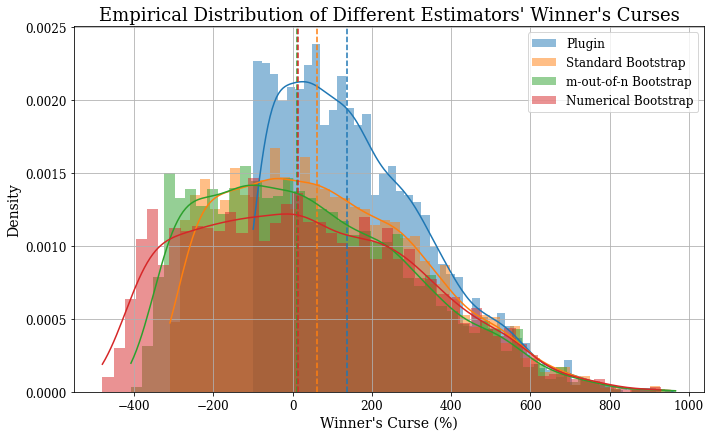

In [45]:
print(wc_pct_df.describe())

fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

# historgram of plugin estimator's winner's curse
sns.histplot(wc_pct_df['plugin'], bins=50, kde=True, stat='density', ax=ax, color='C0', edgecolor=None, label='Plugin')
ax.axvline(wc_pct_df['plugin'].median(), color='C0', linestyle='--')

# historgram of standard bootstrap estimator's winner's curse
sns.histplot(wc_pct_df['stand_bootstrap'], bins=50, kde=True, stat='density', ax=ax, color='C1', edgecolor=None, label='Standard Bootstrap')
ax.axvline(wc_pct_df['stand_bootstrap'].median(), color='C1', linestyle='--')

# historgram of m-out-of-n bootstrap estimator's winner's curse
sns.histplot(wc_pct_df['mn_bootstrap'], bins=50, kde=True, stat='density', ax=ax, color='C2', edgecolor=None, label='m-out-of-n Bootstrap')
ax.axvline(wc_pct_df['mn_bootstrap'].median(), color='C2', linestyle='--')

# historgram of numerical bootstrap estimator's winner's curse
sns.histplot(wc_pct_df['num_bootstrap'], bins=50, kde=True, stat='density', ax=ax, color='C3', edgecolor=None, label='Numerical Bootstrap')
ax.axvline(wc_pct_df['num_bootstrap'].median(), color='C3', linestyle='--')

ax.set_title("Empirical Distribution of Different Estimators' Winner's Curses", fontsize=title_size)
ax.set_xlabel("Winner's Curse (%)", fontsize=axis_label_size)
ax.set_ylabel('Density', fontsize=axis_label_size)
ax.tick_params(axis='both', which='major', labelsize=tick_label_size)
ax.legend(loc='best', fontsize=legend_label_size)
ax.grid()

plt.tight_layout()
plt.show()

       mn_bootstrap  num_bootstrap       plugin  stand_bootstrap
count   3223.000000    3223.000000  3223.000000      3223.000000
mean       8.817230       7.082960    33.887850        18.085102
std       51.694844      56.439289    38.358983        48.835761
min      -81.664545     -96.096549   -19.917381       -61.976386
25%      -32.692637     -38.831905     2.996019       -21.745554
50%        2.227470       2.621198    27.248236        12.475700
75%       44.169352      48.264178    57.590382        51.946621
max      193.339709     185.885030   192.097161       190.708531


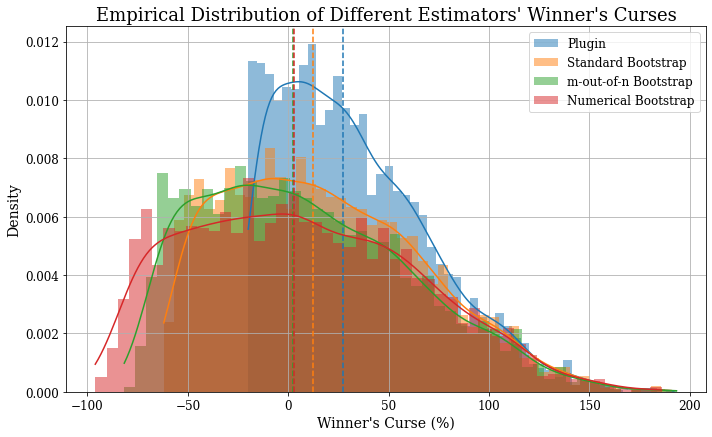

In [46]:
print(roi_wc_df.describe())

fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

# historgram of plugin estimator's winner's curse
sns.histplot(roi_wc_df['plugin'], bins=50, kde=True, stat='density', ax=ax, color='C0', edgecolor=None, label='Plugin')
ax.axvline(roi_wc_df['plugin'].median(), color='C0', linestyle='--')

# historgram of standard bootstrap estimator's winner's curse
sns.histplot(roi_wc_df['stand_bootstrap'], bins=50, kde=True, stat='density', ax=ax, color='C1', edgecolor=None, label='Standard Bootstrap')
ax.axvline(roi_wc_df['stand_bootstrap'].median(), color='C1', linestyle='--')

# historgram of m-out-of-n bootstrap estimator's winner's curse
sns.histplot(roi_wc_df['mn_bootstrap'], bins=50, kde=True, stat='density', ax=ax, color='C2', edgecolor=None, label='m-out-of-n Bootstrap')
ax.axvline(roi_wc_df['mn_bootstrap'].median(), color='C2', linestyle='--')

# historgram of numerical bootstrap estimator's winner's curse
sns.histplot(roi_wc_df['num_bootstrap'], bins=50, kde=True, stat='density', ax=ax, color='C3', edgecolor=None, label='Numerical Bootstrap')
ax.axvline(roi_wc_df['num_bootstrap'].median(), color='C3', linestyle='--')

ax.set_title("Empirical Distribution of Different Estimators' Winner's Curses", fontsize=title_size)
ax.set_xlabel("Winner's Curse (%)", fontsize=axis_label_size)
ax.set_ylabel('Density', fontsize=axis_label_size)
ax.tick_params(axis='both', which='major', labelsize=tick_label_size)
ax.legend(loc='best', fontsize=legend_label_size)
ax.grid()

plt.tight_layout()
plt.show()

# Sensitivity Analysis

## Hyperparameter: tau

### m-out-of-n

In [60]:
targeting_params = {'price': 1, 'cost': 0.5}

dgp_params = {'te': np.nan, 'noise_std': 5, 'treatment_space': np.array([0, 1])}

data_params = {'sample_size': 200}

experiment_params = {'n_experiments': 1000}

estimators_dict = {
    'stand_bootstrap': {
        'estimator': btss.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'bootstrap_method': 'standard'}
    }, 
    'mn_bootstrap': {
        'estimator': btss.bootstrap_correction_estimate, 
        'params': {
            'n_bootstraps': 500, 'bootstrap_method': 'm_out_of_n', 
            'power': np.nan
        }
    }, 
}

In [ ]:
te_list = [-0.2, 0, 0.2, 0.4, 0.5, 0.6, 0.8, 1]
power_list = [0.88, 0.90, 0.92, 0.95, 0.97]
result_dict = {(te, power): None for te in te_list for power in power_list}

for te in te_list:
    dgp_params['te'] = te
    for power in power_list: 
        print(f'Te = {te}, Power = {power}')
        estimators_dict['mn_bootstrap']['params']['power'] = power
        
        result_record = btss.repeated_experiments(
            operations_params=operations_params, 
            dgp_params=dgp_params, 
            data_params=data_params, 
            experiment_params=experiment_params, 
            estimators_dict=estimators_dict, 
            verbose=True, n_jobs=-1
        )

        wc_df = pd.DataFrame({
            name: np.array([record[f'{name}_wc'] for record in result_record]) 
            for name in list(estimators_dict.keys()) + ['plugin']
        })

        result_dict[(te, power)] = {
            f'{col}_mean': wc_df[col].mean() for col in wc_df.columns
        }

        result_dict[(te, power)].update({
            f'{col}_se': wc_df[col].std() / np.sqrt(data_params['sample_size'])
            for col in wc_df.columns
        })

with open('results/case1_mnb_hyperparam_test.pkl', 'wb') as f:
    pickle.dump(result_dict, f)

In [58]:
with open('results/case1_mnb_hyperparam_test.pkl', 'rb') as f:
    result_dict = pickle.load(f)

result_df = pd.DataFrame.from_records([
    {
        'tau': tau, 'power': power, 
        **result_dict[(tau, power)]
    } for tau, power in result_dict.keys()
])

tau_arr = np.unique(result_df['tau'])
power_arr = np.unique(result_df['power'])

plugin_df = result_df[result_df['power'] == power_arr[0]][['tau', 'plugin_mean']]
bootstrap_df = result_df[result_df['power'] == power_arr[0]][['tau', 'stand_bootstrap_mean']]
best_wc_list = [None] * len(tau_arr)
for idx, tau in enumerate(tau_arr):
    temp = result_df[result_df['tau'] == tau][['power', 'mn_bootstrap_mean']]
    best_wc_list[idx] = temp['mn_bootstrap_mean'].loc[(-temp['mn_bootstrap_mean'].abs()).idxmax()]

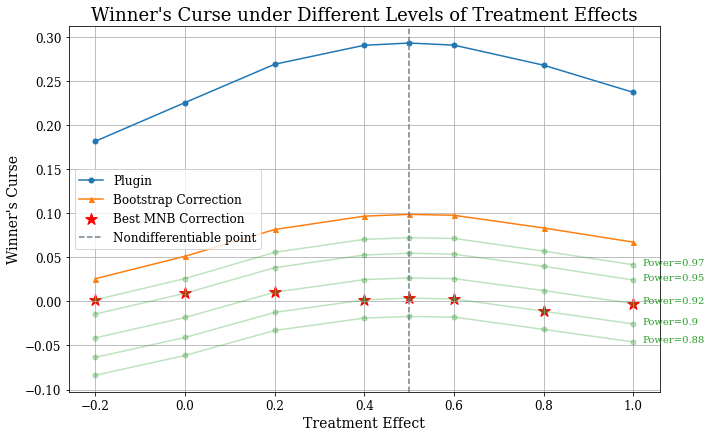

In [61]:
fig, ax = plt.subplots(figsize=(10, 6.18))

# plot plugin estimator
ax.plot(plugin_df['tau'], plugin_df['plugin_mean'], 'o-', markersize=5, label='Plugin', color='C0')

# plot bootstrap estimator
ax.plot(bootstrap_df['tau'], bootstrap_df['stand_bootstrap_mean'], '^-', markersize=5, label='Bootstrap Correction', color='C1')

# plot m out of n bootstrap estimator
for power in power_arr:
    mnb_df = result_df[result_df['power'] == power][['tau', 'mn_bootstrap_mean']]
    ax.plot(mnb_df['tau'], mnb_df['mn_bootstrap_mean'], 'o-', color='C2', alpha=0.3, markersize=5)
    ax.text(
        1.02, mnb_df[mnb_df['tau'] == 1.0]['mn_bootstrap_mean'].values[0], 
        f'Power={power}', 
        fontsize=10, color='C2'
    )

# mark the best hyperparameters for each tau
ax.scatter(tau_arr, best_wc_list, color='red', marker='*', s=150, label='Best MNB Correction')

# plot the nondifferentiable point
ax.axvline(targeting_params['cost'] / targeting_params['price'], color='slategray', linestyle='--', label='Nondifferentiable point')

ax.set_title("Winner's Curse under Different Levels of Treatment Effects", fontsize=title_size)
ax.set_xlabel('Treatment Effect', fontsize=axis_label_size)
ax.set_ylabel("Winner's Curse", fontsize=axis_label_size)
ax.legend(loc='best', fontsize=legend_label_size)
ax.tick_params(axis='both', which='major', labelsize=tick_label_size)
ax.grid()

plt.tight_layout()
plt.savefig('figures/case1-mnb-hyperparam-test.png')
plt.show()

### Numerical bootstrap

In [22]:
targeting_params = {'price': 1, 'cost': 0.5}

dgp_params = {'te': np.nan, 'noise_std': 5, 'treatment_space': np.array([0, 1])}

data_params = {'sample_size': 200}

experiment_params = {'n_experiments': 1000}

estimators_dict = {
    'stand_bootstrap': {
        'estimator': btss.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'bootstrap_method': 'standard'}
    }, 
    'num_bootstrap': {
        'estimator': btss.bootstrap_correction_estimate, 
        'params': {
            'n_bootstraps': 500, 'bootstrap_method': 'numerical', 
            'power': np.nan
        }
    },
}

In [ ]:
te_list = [-0.2, 0, 0.2, 0.4, 0.5, 0.6, 0.8, 1]
power_list = [-0.35, -0.40, -0.43, -0.45, -0.49]
result_dict = {(te, power): None for te in te_list for power in power_list}

for te in te_list:
    dgp_params['te'] = te
    for power in power_list: 
        print(f'\nTE = {te}, Power = {power}')
        estimators_dict['num_bootstrap']['params']['power'] = power
        
        result_record = btss.repeated_experiments(
            operations_params=operations_params, 
            dgp_params=dgp_params, 
            data_params=data_params, 
            experiment_params=experiment_params, 
            estimators_dict=estimators_dict, 
            verbose=True, n_jobs=-1
        )

        wc_df = pd.DataFrame({
            name: np.array([record[f'{name}_wc'] for record in result_record]) 
            for name in list(estimators_dict.keys()) + ['plugin']
        })

        result_dict[(te, power)] = {
            f'{col}_mean': wc_df[col].mean() for col in wc_df.columns
        }

        result_dict[(te, power)].update({
            f'{col}_se': wc_df[col].std() / np.sqrt(data_params['sample_size'])
            for col in wc_df.columns
        })

with open('results/case1_numb_hyperparam_test.pkl', 'wb') as f:
    pickle.dump(result_dict, f)

In [62]:
with open('results/case1_numb_hyperparam_test.pkl', 'rb') as f:
    result_dict = pickle.load(f)

result_df = pd.DataFrame.from_records([
    {
        'tau': tau, 'power': power, 
        **result_dict[(tau, power)]
    } for tau, power in result_dict.keys()
])

tau_arr = np.unique(result_df['tau'])
power_arr = np.unique(result_df['power'])

plugin_df = result_df[result_df['power'] == power_arr[0]][['tau', 'plugin_mean']]
bootstrap_df = result_df[result_df['power'] == power_arr[0]][['tau', 'stand_bootstrap_mean']]
best_wc_list = [None] * len(tau_arr)
for idx, tau in enumerate(tau_arr):
    temp = result_df[result_df['tau'] == tau][['power', 'num_bootstrap_mean']]
    best_wc_list[idx] = temp['num_bootstrap_mean'].loc[(-temp['num_bootstrap_mean'].abs()).idxmax()]

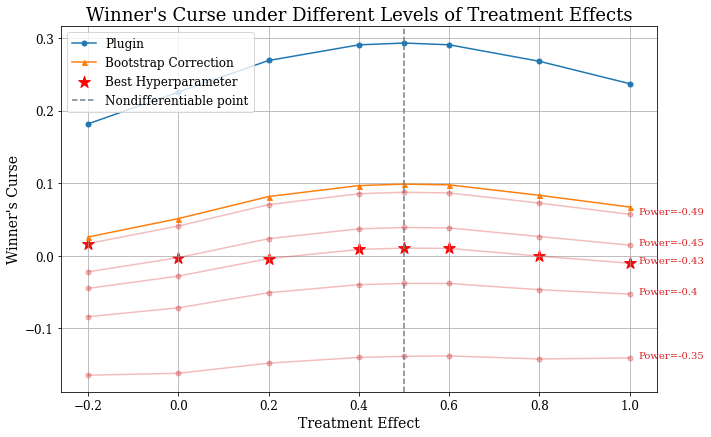

In [63]:
fig, ax = plt.subplots(figsize=(10, 6.18))

# plot plugin estimator
ax.plot(plugin_df['tau'], plugin_df['plugin_mean'], 'o-', markersize=5, label='Plugin', color='C0')

# plot bootstrap estimator
ax.plot(bootstrap_df['tau'], bootstrap_df['stand_bootstrap_mean'], '^-', markersize=5, label='Bootstrap Correction', color='C1')

# plot m out of n bootstrap estimator
for power in power_arr:
    mnb_df = result_df[result_df['power'] == power][['tau', 'num_bootstrap_mean']]
    ax.plot(mnb_df['tau'], mnb_df['num_bootstrap_mean'], 'o-', color='C3', alpha=0.3, markersize=5)
    ax.text(
        1.02, mnb_df[mnb_df['tau'] == 1.0]['num_bootstrap_mean'].values[0], 
        f'Power={power}', 
        fontsize=10, color='C3'
    )

# mark the best hyperparameters for each tau
ax.scatter(tau_arr, best_wc_list, color='red', marker='*', s=150, label='Best Hyperparameter')

# plot the nondifferentiable point
ax.axvline(targeting_params['cost'] / targeting_params['price'], color='slategray', linestyle='--', label='Nondifferentiable point')

ax.set_title("Winner's Curse under Different Levels of Treatment Effects", fontsize=title_size)
ax.set_xlabel('Treatment Effect', fontsize=axis_label_size)
ax.set_ylabel("Winner's Curse", fontsize=axis_label_size)
ax.legend(loc='best', fontsize=legend_label_size)
ax.tick_params(axis='both', which='major', labelsize=tick_label_size)
ax.grid()

plt.tight_layout()
plt.savefig('figures/case1-numb-hyperparam-test.png')
plt.show()

## Hyperparameter: noise level

### m-out-of-n

In [31]:
targeting_params = {'price': 1, 'cost': 0.5}

dgp_params = {'te': 0.6, 'noise_std': np.nan, 'treatment_space': np.array([0, 1])}

data_params = {'sample_size': 500}

experiment_params = {'n_experiments': 1000, 'conditional_on_treated': True, 'stats': 'mean'}

estimators_dict = {
    'stand_bootstrap': {
        'estimator': btss.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'bootstrap_method': 'standard'}
    }, 
    'mn_bootstrap': {
        'estimator': btss.bootstrap_correction_estimate, 
        'params': {
            'n_bootstraps': 500, 'bootstrap_method': 'm_out_of_n', 
            'power': np.nan
        }
    }, 
}

In [ ]:
noise_level_list = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
power_list = [0.75, 0.80, 0.85, 0.90, 0.95]
result_dict = {(noise_level, power): None for noise_level in noise_level_list for power in power_list}

for noise_level in noise_level_list:
    dgp_params['noise_std'] = noise_level
    for power in power_list: 
        print(f'Noise Level = {noise_level}, Power = {power}')
        estimators_dict['mn_bootstrap']['params']['power'] = power
        
        result_record = btss.repeated_experiments(
            operations_params=operations_params, 
            dgp_params=dgp_params, 
            data_params=data_params, 
            experiment_params=experiment_params, 
            estimators_dict=estimators_dict, 
            verbose=True, n_jobs=-1
        )

        wc_df = pd.DataFrame({
            name: np.array([record[f'{name}_wc'] for record in result_record]) 
            for name in list(estimators_dict.keys()) + ['plugin']
        })

        result_dict[(noise_level, power)] = {
            f'{col}_mean': wc_df[col].mean() for col in wc_df.columns
        }

        result_dict[(noise_level, power)].update({
            f'{col}_se': wc_df[col].std() / np.sqrt(data_params['sample_size'])
            for col in wc_df.columns
        })

with open('results/case1_mnb_hyperparam_noise_level_test.pkl', 'wb') as f:
    pickle.dump(result_dict, f)

In [ ]:
with open('results/case1_mnb_hyperparam_noise_level_test.pkl', 'rb') as f:
    result_dict = pickle.load(f)

result_df = pd.DataFrame.from_records([
    {
        'noise_level': noise_level, 'power': power, 
        **result_dict[(noise_level, power)]
    } for noise_level, power in result_dict.keys()
])

noise_level_arr = np.unique(result_df['noise_level'])
power_arr = np.unique(result_df['power'])

plugin_df = result_df[result_df['power'] == power_arr[0]][['noise_level', 'plugin_mean']]
bootstrap_df = result_df[result_df['power'] == power_arr[0]][['noise_level', 'stand_bootstrap_mean']]
best_wc_list = [None] * len(noise_level_arr)
for idx, noise_level in enumerate(noise_level_arr):
    temp = result_df[result_df['noise_level'] == noise_level][['power', 'mn_bootstrap_mean']]
    best_wc_list[idx] = temp['mn_bootstrap_mean'].loc[(-temp['mn_bootstrap_mean'].abs()).idxmax()]

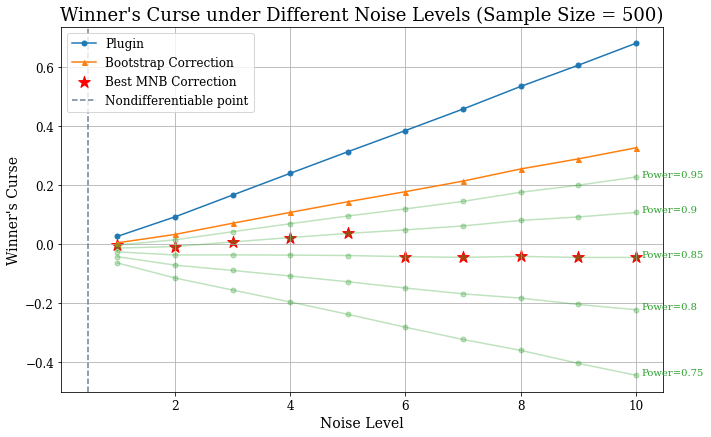

In [117]:
fig, ax = plt.subplots(figsize=(10, 6.18))

# plot plugin estimator
ax.plot(plugin_df['noise_level'], plugin_df['plugin_mean'], 'o-', markersize=5, label='Plugin', color='C0')

# plot bootstrap estimator
ax.plot(bootstrap_df['noise_level'], bootstrap_df['stand_bootstrap_mean'], '^-', markersize=5, label='Bootstrap Correction', color='C1')

# plot m out of n bootstrap estimator
for power in power_arr:
    mnb_df = result_df[result_df['power'] == power][['noise_level', 'mn_bootstrap_mean', 'mn_bootstrap_se']]
    ax.plot(mnb_df['noise_level'], mnb_df['mn_bootstrap_mean'], 'o-', color='C2', alpha=0.3, markersize=5)
    ax.text(
        10.1, mnb_df[mnb_df['noise_level'] == 10]['mn_bootstrap_mean'].values[0], 
        f'Power={power}', 
        fontsize=10, color='C2'
    )
    # ax.fill_between(
    #     mnb_df['noise_level'], 
    #     mnb_df['mn_bootstrap_mean'] - 1.96 * mnb_df['mn_bootstrap_se'], 
    #     mnb_df['mn_bootstrap_mean'] + 1.96 * mnb_df['mn_bootstrap_se'], 
    #     color='C2', alpha=0.3
    # )

# mark the best hyperparameters for each tau
ax.scatter(noise_level_arr, best_wc_list, color='red', marker='*', s=150, label='Best MNB Correction')

# plot the nondifferentiable point
ax.axvline(targeting_params['cost'] / targeting_params['price'], color='slategray', linestyle='--', label='Nondifferentiable point')

ax.set_title(f"Winner's Curse under Different Noise Levels (Sample Size = {data_params['sample_size']})", fontsize=title_size)
ax.set_xlabel('Noise Level', fontsize=axis_label_size)
ax.set_ylabel("Winner's Curse", fontsize=axis_label_size)
ax.legend(loc='best', fontsize=legend_label_size)
ax.tick_params(axis='both', which='major', labelsize=tick_label_size)
ax.grid()

plt.tight_layout()
plt.savefig('figures/case1-mnb-hyperparam-noise-level-test.png')
plt.show()

## Sample Size

In [52]:
operations_params = {'price': 1, 'cost': 0.5}

dgp_params = {'te': 0.6, 'noise_std': 2, 'treatment_space': np.array([0, 1])}

data_params = {'sample_size': np.nan}

experiment_params = {'n_experiments': 10000, 'conditional_on_treated': True, 'stats': 'mean'}

estimators_dict = {
    'stand_bootstrap': {
        'estimator': btss.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'bootstrap_method': 'standard'}
    }, 
    'mn_bootstrap': {
        'estimator': btss.bootstrap_correction_estimate, 
        'params': {
            'n_bootstraps': 500, 'bootstrap_method': 'm_out_of_n', 
            'power': 0.95
        }
    }, 
    'num_bootstrap': {
        'estimator': btss.bootstrap_correction_estimate, 
        'params': {
            'n_bootstraps': 500, 'bootstrap_method': 'numerical', 
            'power': - 0.45
        }
    }
}

In [53]:
sample_size_list = [100, 200, 300, 400, 500, 750, 1000, 2000, 3000, 4000, 5000]

result_dict = btss.sample_size_test(
    sample_sizes=sample_size_list, 
    operations_params=operations_params,
    dgp_params=dgp_params,
    data_params=data_params,
    experiment_params=experiment_params,
    estimators_dict=estimators_dict,
    n_jobs=-1, verbose=True, 
    save_path='results/case1_sample_size_test.pkl'
)


Running sample size 100 (1/11)
Running 10000 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done 1100 tasks      | elapsed:    3.9s
[Parallel(n_jobs=-1)]: Done 3100 tasks      | elapsed:   10.6s
[Parallel(n_jobs=-1)]: Done 5900 tasks      | elapsed:   19.5s
[Parallel(n_jobs=-1)]: Done 9500 tasks      | elapsed:   29.9s
[Parallel(n_jobs=-1)]: Done 10000 out of 10000 | elapsed:   31.2s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.


Finished sample size 100 in 0:00:31.225367

Running sample size 200 (2/11)
Running 10000 experiments...


[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done 1100 tasks      | elapsed:    4.0s
[Parallel(n_jobs=-1)]: Done 3100 tasks      | elapsed:   10.5s
[Parallel(n_jobs=-1)]: Done 5900 tasks      | elapsed:   19.4s
[Parallel(n_jobs=-1)]: Done 9500 tasks      | elapsed:   31.0s
[Parallel(n_jobs=-1)]: Done 10000 out of 10000 | elapsed:   32.5s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.


Finished sample size 200 in 0:00:32.552766

Running sample size 300 (3/11)
Running 10000 experiments...


...

[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.5s
[Parallel(n_jobs=-1)]: Done 340 tasks      | elapsed:    3.7s
[Parallel(n_jobs=-1)]: Done 840 tasks      | elapsed:    8.7s
[Parallel(n_jobs=-1)]: Done 1540 tasks      | elapsed:   15.9s
[Parallel(n_jobs=-1)]: Done 2440 tasks      | elapsed:   25.2s
[Parallel(n_jobs=-1)]: Done 3540 tasks      | elapsed:   37.3s
[Parallel(n_jobs=-1)]: Done 4840 tasks      | elapsed:   53.5s
[Parallel(n_jobs=-1)]: Done 6340 tasks      | elapsed:  1.2min
[Parallel(n_jobs=-1)]: Done 8040 tasks      | elapsed:  1.5min
[Parallel(n_jobs=-1)]: Done 9940 tasks      | elapsed:  1.8min
[Parallel(n_jobs=-1)]: Done 10000 out of 10000 | elapsed:  1.8min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.


Finished sample size 4000 in 0:01:48.523850

Running sample size 5000 (11/11)
Running 10000 experiments...


[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.8s
[Parallel(n_jobs=-1)]: Done 340 tasks      | elapsed:    6.3s
[Parallel(n_jobs=-1)]: Done 840 tasks      | elapsed:   15.2s
[Parallel(n_jobs=-1)]: Done 1540 tasks      | elapsed:   27.7s
[Parallel(n_jobs=-1)]: Done 2440 tasks      | elapsed:   44.5s
[Parallel(n_jobs=-1)]: Done 3540 tasks      | elapsed:  1.1min
[Parallel(n_jobs=-1)]: Done 4840 tasks      | elapsed:  1.5min
[Parallel(n_jobs=-1)]: Done 6340 tasks      | elapsed:  2.0min
[Parallel(n_jobs=-1)]: Done 8040 tasks      | elapsed:  2.4min
[Parallel(n_jobs=-1)]: Done 9940 tasks      | elapsed:  3.0min


Finished sample size 5000 in 0:03:01.286759


[Parallel(n_jobs=-1)]: Done 10000 out of 10000 | elapsed:  3.0min finished


In [54]:
with open('results/case1_sample_size_test.pkl', 'rb') as f:
    result_dict = pickle.load(f)

result_df = pd.DataFrame.from_dict(result_dict).T

In [8]:
def visualize_sensitivity_test(
    label: str, 
    estimators_list: list, result_df: pd.DataFrame, 
    metric: str, plot_error_bar: bool = True, 
    save_path: str = None, 
):
    assert metric in ['wc', 'wc_pct', 'roi_wc'], "Invalid metric"

    pct_multiplier = 100 if metric == 'wc_pct' or metric == 'roi_wc' else 1

    fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

    for idx, estimator in enumerate(estimators_list):
        ax.plot(
            result_df.index, 
            result_df[f'{estimator}_{metric}_mean'] * pct_multiplier,
            'o-', markersize=5, label=estimator, 
            color=f'C{idx}'
        )
        if plot_error_bar:
            ax.fill_between(
                result_df.index, 
                pct_multiplier * (result_df[f'{estimator}_{metric}_mean'] - 1.96 * result_df[f'{estimator}_{metric}_se']), 
                pct_multiplier * (result_df[f'{estimator}_{metric}_mean'] + 1.96 * result_df[f'{estimator}_{metric}_se']), 
                color=f'C{idx}', alpha=0.3
            )

    ax.set_title("Winner's Curse of Different Estimators", fontsize=title_size)
    ax.set_xlabel(label, fontsize=axis_label_size)
    if metric == 'wc':
        ax.set_ylabel("Winner's Curse", fontsize=axis_label_size)
    else:
        ax.set_ylabel("Winner's Curse (%)", fontsize=axis_label_size)
    ax.tick_params(axis='both', which='major', labelsize=tick_label_size)
    ax.grid()
    ax.legend(loc='best', fontsize=legend_label_size)

    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path)
    plt.show()    

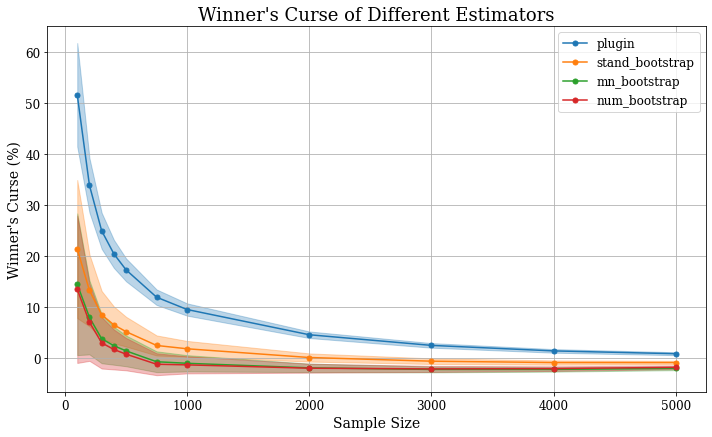

In [56]:
visualize_sensitivity_test(
    estimators_list=['plugin', 'stand_bootstrap', 'mn_bootstrap', 'num_bootstrap'], 
    result_df=result_df, metric='roi_wc', plot_error_bar=True, 
    save_path=None
)

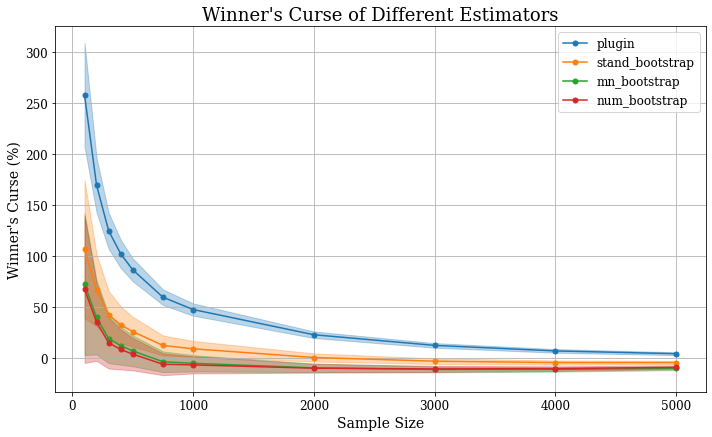

In [57]:
visualize_sample_size_test(
    estimators_list=['plugin', 'stand_bootstrap', 'mn_bootstrap', 'num_bootstrap'], 
    result_df=result_df, metric='wc_pct', plot_error_bar=True, 
    save_path=None
)

## Noise Level

In [6]:
operations_params = {'price': 1, 'cost': 0.5}

dgp_params = {'te': 0.6, 'noise_std': np.nan, 'treatment_space': np.array([0, 1])}

data_params = {'sample_size': 1000}

experiment_params = {'n_experiments': 10000, 'conditional_on_treated': True, 'stats': 'mean'}

estimators_dict = {
    'stand_bootstrap': {
        'estimator': btss.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'bootstrap_method': 'standard'}
    }, 
    'mn_bootstrap': {
        'estimator': btss.bootstrap_correction_estimate, 
        'params': {
            'n_bootstraps': 500, 'bootstrap_method': 'm_out_of_n', 
            'power': 0.95
        }
    }, 
    'num_bootstrap': {
        'estimator': btss.bootstrap_correction_estimate, 
        'params': {
            'n_bootstraps': 500, 'bootstrap_method': 'numerical', 
            'power': - 0.45
        }
    }
}

In [7]:
noise_level_list = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

result_dict = btss.noise_level_test(
    noise_levels=noise_level_list, 
    operations_params=operations_params,
    dgp_params=dgp_params,
    data_params=data_params,
    experiment_params=experiment_params,
    estimators_dict=estimators_dict,
    n_jobs=-1, verbose=True, 
    save_path='results/case1_noise_level_test.pkl'
)


Running noise level 1 (1/10)
Running 10000 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:    2.0s
[Parallel(n_jobs=-1)]: Done 500 tasks      | elapsed:    5.1s
[Parallel(n_jobs=-1)]: Done 1500 tasks      | elapsed:   11.2s
[Parallel(n_jobs=-1)]: Done 2900 tasks      | elapsed:   19.9s
[Parallel(n_jobs=-1)]: Done 4700 tasks      | elapsed:   30.9s
[Parallel(n_jobs=-1)]: Done 6900 tasks      | elapsed:   44.4s
[Parallel(n_jobs=-1)]: Done 9500 tasks      | elapsed:  1.0min
[Parallel(n_jobs=-1)]: Done 10000 out of 10000 | elapsed:  1.1min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.


Finished noise level 1 in 0:01:04.193178

Running noise level 2 (2/10)
Running 10000 experiments...


[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.3s
[Parallel(n_jobs=-1)]: Done 620 tasks      | elapsed:    3.3s
[Parallel(n_jobs=-1)]: Done 1620 tasks      | elapsed:    8.5s
[Parallel(n_jobs=-1)]: Done 3020 tasks      | elapsed:   15.7s
[Parallel(n_jobs=-1)]: Done 4820 tasks      | elapsed:   24.8s
[Parallel(n_jobs=-1)]: Done 7020 tasks      | elapsed:   36.1s
[Parallel(n_jobs=-1)]: Done 9620 tasks      | elapsed:   49.3s
[Parallel(n_jobs=-1)]: Done 9981 out of 10000 | elapsed:   51.1s remaining:    0.1s
[Parallel(n_jobs=-1)]: Done 10000 out of 10000 | elapsed:   51.2s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.


Finished noise level 2 in 0:00:51.218024

Running noise level 3 (3/10)
Running 10000 experiments...


...

[Parallel(n_jobs=-1)]: Done 1100 tasks      | elapsed:    4.2s
[Parallel(n_jobs=-1)]: Done 3100 tasks      | elapsed:   11.7s
[Parallel(n_jobs=-1)]: Done 5900 tasks      | elapsed:   21.8s
[Parallel(n_jobs=-1)]: Done 9500 tasks      | elapsed:   35.3s
[Parallel(n_jobs=-1)]: Done 10000 out of 10000 | elapsed:   37.1s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.1s


Finished noise level 9 in 0:00:37.068858

Running noise level 10 (10/10)
Running 10000 experiments...


[Parallel(n_jobs=-1)]: Done 1100 tasks      | elapsed:    4.0s
[Parallel(n_jobs=-1)]: Done 3100 tasks      | elapsed:   11.5s
[Parallel(n_jobs=-1)]: Done 5900 tasks      | elapsed:   21.9s
[Parallel(n_jobs=-1)]: Done 9500 tasks      | elapsed:   34.9s


Finished noise level 10 in 0:00:36.755580


[Parallel(n_jobs=-1)]: Done 10000 out of 10000 | elapsed:   36.7s finished


In [10]:
with open('results/case1_noise_level_test.pkl', 'rb') as f:
    result_dict = pickle.load(f)

result_df = pd.DataFrame.from_dict(result_dict).T

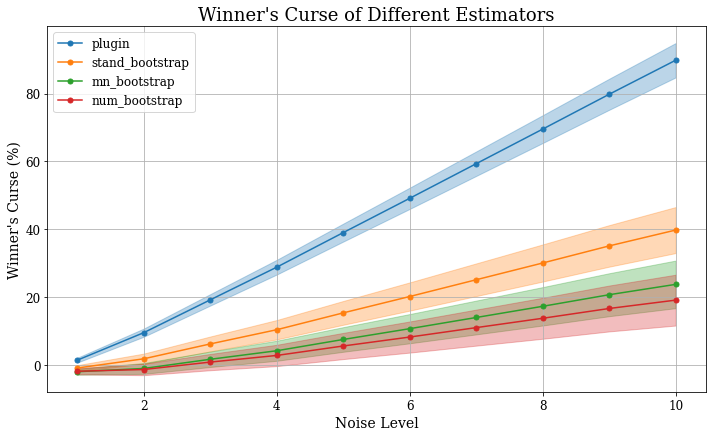

In [13]:
visualize_sensitivity_test(
    label='Noise Level', 
    estimators_list=['plugin', 'stand_bootstrap', 'mn_bootstrap', 'num_bootstrap'], 
    result_df=result_df, metric='roi_wc', plot_error_bar=True, 
    save_path=None
)

## Sample Size and Noise Level

In [54]:
operations_params = {'price': 1, 'cost': 0.5}

dgp_params = {'te': 0.6, 'noise_std': np.nan, 'treatment_space': np.array([0, 1])}

data_params = {'sample_size': np.nan}

experiment_params = {'n_experiments': 1000, 'conditional_on_treated': True, 'stats': 'mean'}

estimators_dict = {
    'stand_bootstrap': {
        'estimator': btss.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'bootstrap_method': 'standard'}
    }, 
    'mn_bootstrap': {
        'estimator': btss.bootstrap_correction_estimate, 
        'params': {
            'n_bootstraps': 500, 'bootstrap_method': 'm_out_of_n', 
            'power': 0.95
        }
    }, 
    'num_bootstrap': {
        'estimator': btss.bootstrap_correction_estimate, 
        'params': {
            'n_bootstraps': 500, 'bootstrap_method': 'numerical', 
            'power': - 0.45
        }
    }
}

In [55]:
sample_size_list = [100, 1000, 5000, 10000, 50000]
noise_level_list = [1, 3, 5, 7, 10]

result_dict = {(sample_size, noise_level): None for sample_size in sample_size_list for noise_level in noise_level_list}

for sample_size in sample_size_list:
    for noise_level in noise_level_list:
        data_params['sample_size'] = sample_size
        dgp_params['noise_std'] = noise_level
        print(f'\nSample Size: {sample_size}, Noise Level: {noise_level}')

        result_list = btss.repeated_experiments(
            operations_params=operations_params, 
            dgp_params=dgp_params, 
            data_params=data_params, 
            experiment_params=experiment_params, 
            estimators_dict=estimators_dict, 
            verbose=True, n_jobs=-1
        )

        result_dict[(sample_size, noise_level)] = result_list


Sample Size: 100, Noise Level: 1
Running 1000 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:    2.2s
[Parallel(n_jobs=-1)]: Done 820 tasks      | elapsed:    5.0s
[Parallel(n_jobs=-1)]: Done 1000 out of 1000 | elapsed:    5.5s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.1s



Sample Size: 100, Noise Level: 3
Running 1000 experiments...


[Parallel(n_jobs=-1)]: Done 946 tasks      | elapsed:    2.9s
[Parallel(n_jobs=-1)]: Done 1000 out of 1000 | elapsed:    3.0s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.1s



Sample Size: 100, Noise Level: 5
Running 1000 experiments...


...

[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:    4.6s
[Parallel(n_jobs=-1)]: Done 180 tasks      | elapsed:   27.1s
[Parallel(n_jobs=-1)]: Done 430 tasks      | elapsed:  1.1min
[Parallel(n_jobs=-1)]: Done 780 tasks      | elapsed:  2.0min
[Parallel(n_jobs=-1)]: Done 1000 out of 1000 | elapsed:  2.5min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.



Sample Size: 50000, Noise Level: 7
Running 1000 experiments...


[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:    4.9s
[Parallel(n_jobs=-1)]: Done 180 tasks      | elapsed:   26.0s
[Parallel(n_jobs=-1)]: Done 430 tasks      | elapsed:  1.0min
[Parallel(n_jobs=-1)]: Done 780 tasks      | elapsed:  1.8min
[Parallel(n_jobs=-1)]: Done 1000 out of 1000 | elapsed:  2.3min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.



Sample Size: 50000, Noise Level: 10
Running 1000 experiments...


[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    6.3s
[Parallel(n_jobs=-1)]: Done 200 tasks      | elapsed:   25.2s
[Parallel(n_jobs=-1)]: Done 450 tasks      | elapsed:   54.5s
[Parallel(n_jobs=-1)]: Done 800 tasks      | elapsed:  1.7min
[Parallel(n_jobs=-1)]: Done 1000 out of 1000 | elapsed:  2.1min finished


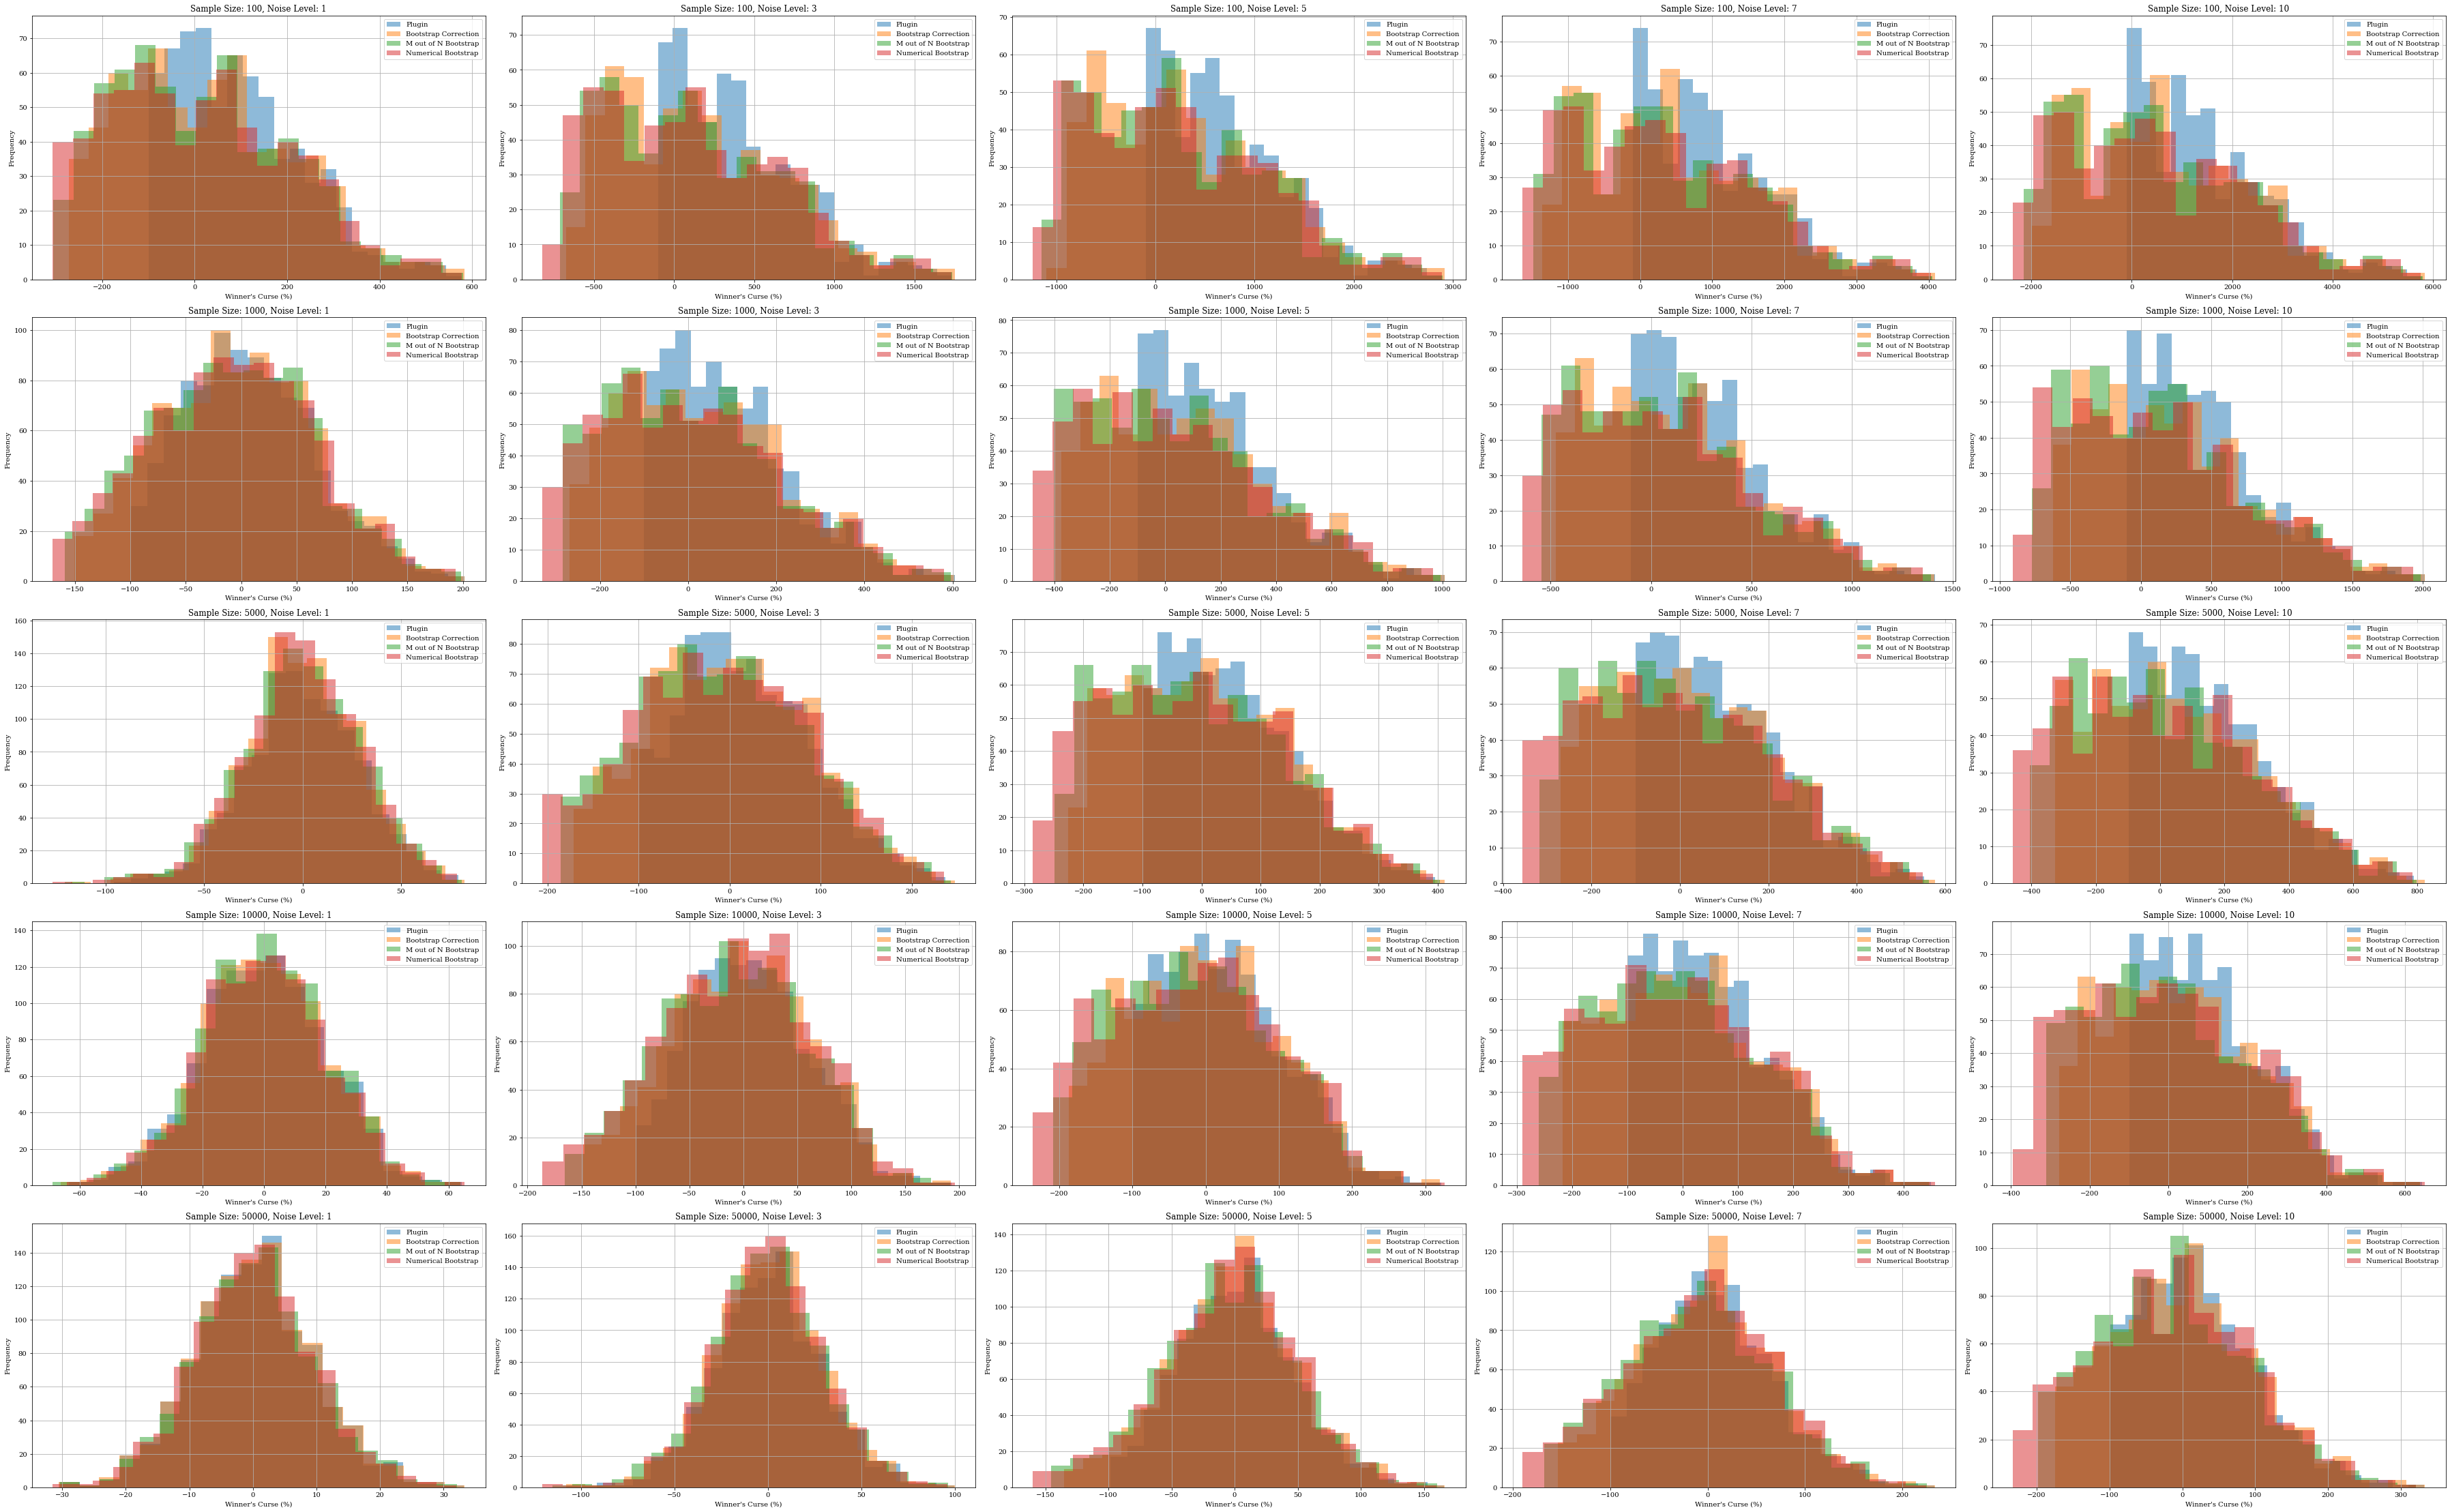

In [56]:
fig, axes = plt.subplots(len(sample_size_list), len(noise_level_list), figsize=(10 * len(sample_size_list), 6.18 * len(noise_level_list)))

for idx, sample_size in enumerate(sample_size_list):
    for jdx, noise_level in enumerate(noise_level_list):
        ax = axes[idx, jdx]
        result_list = result_dict[(sample_size, noise_level)]
        wc_df = pd.DataFrame({
            name: 100 * np.array([record[f'{name}_wc_pct'] for record in result_list]) 
            for name in list(estimators_dict.keys()) + ['plugin']
        })
        ax.hist(wc_df['plugin'], bins=20, alpha=0.5, label='Plugin')
        ax.hist(wc_df['stand_bootstrap'], bins=20, alpha=0.5, label='Bootstrap Correction')
        ax.hist(wc_df['mn_bootstrap'], bins=20, alpha=0.5, label='M out of N Bootstrap')
        ax.hist(wc_df['num_bootstrap'], bins=20, alpha=0.5, label='Numerical Bootstrap')
        ax.set_title(f'Sample Size: {sample_size}, Noise Level: {noise_level}')
        ax.grid()
        ax.legend()
        ax.set_xlabel('Winner\'s Curse (%)')
        ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()


In [ ]:
avg_wc_pct_df = pd.DataFrame.from_dict({
    key: {
        estimator: np.mean([dict_[f'{estimator}_wc_pct'] for dict_ in record_list])
        for estimator in list(estimators_dict.keys()) + ['plugin']
    } for key, record_list in result_dict.items()
}).T.reset_index().rename(columns={'level_0': 'sample_size', 'level_1': 'noise_level'})

se_wc_pct_df = pd.DataFrame.from_dict({
    key: {
        estimator: np.std([dict_[f'{estimator}_wc_pct'] for dict_ in record_list]) / np.sqrt(key[0])
        for estimator in list(estimators_dict.keys()) + ['plugin']
    } for key, record_list in result_dict.items()
}).T.reset_index().rename(columns={'level_0': 'sample_size', 'level_1': 'noise_level'})

avg_roi_wc_pct_df = pd.DataFrame.from_dict({
    key: {
        estimator: np.mean([dict_[f'{estimator}_roi_wc'] for dict_ in record_list])
        for estimator in list(estimators_dict.keys()) + ['plugin']
    } for key, record_list in result_dict.items()
}).T.reset_index().rename(columns={'level_0': 'sample_size', 'level_1': 'noise_level'})

se_roi_wc_pct_df = pd.DataFrame.from_dict({
    key: {
        estimator: np.std([dict_[f'{estimator}_roi_wc'] for dict_ in record_list]) / np.sqrt(key[0])
        for estimator in list(estimators_dict.keys()) + ['plugin']
    } for key, record_list in result_dict.items()
}).T.reset_index().rename(columns={'level_0': 'sample_size', 'level_1': 'noise_level'})


In [60]:
sample_size = 1000

avg_wc_pct_df[avg_wc_pct_df['sample_size'] == sample_size].drop(columns=['sample_size'])

,noise_level,stand_bootstrap,mn_bootstrap,num_bootstrap,plugin
5,1,-3.318224,-8.651455,-7.859900,8.180206
6,3,33.788757,11.856037,7.538146,98.722157
7,5,79.993102,41.579584,31.671175,198.471746
8,7,132.248199,77.118802,62.193938,302.749165
9,10,216.502250,136.801507,114.413403,463.119715


In [61]:
se_wc_pct_df[se_wc_pct_df['sample_size'] == sample_size].drop(columns=['sample_size'])

,noise_level,stand_bootstrap,mn_bootstrap,num_bootstrap,plugin
5,1,2.175553,2.271291,2.319960,1.833531
6,3,5.740617,5.938687,6.288321,4.425156
7,5,9.238329,9.558386,10.166798,7.010225
8,7,12.701563,13.147761,13.997125,9.581368
9,10,17.806736,18.449547,19.665754,13.408640


In [126]:
noise_level = 1

avg_wc_pct_df[avg_wc_pct_df['noise_level'] == noise_level].drop(columns=['noise_level'])

,sample_size,stand_bootstrap,mn_bootstrap,num_bootstrap,plugin
0,100,29.035704,13.063177,10.703290,98.599086
5,1000,-3.318224,-8.651455,-7.859900,8.180206
10,5000,-0.096065,-0.775123,-0.382143,0.262325
15,10000,0.010301,0.016033,0.048003,0.059030
20,50000,0.093335,0.097730,0.103345,0.086484


In [127]:
se_wc_pct_df[se_wc_pct_df['noise_level'] == noise_level].drop(columns=['noise_level'])

,sample_size,stand_bootstrap,mn_bootstrap,num_bootstrap,plugin
0,100,18.075287,18.555999,19.208606,13.682827
5,1000,2.175553,2.271291,2.319960,1.833531
10,5000,0.407499,0.418524,0.413310,0.396375
15,10000,0.198918,0.199800,0.199070,0.198142
20,50000,0.041839,0.041760,0.041731,0.041797


# Robustness Tests